In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn as sk
import sklearn.model_selection
import torch
from google.colab import drive
import os
import cv2
import copy

In [ ]:
drive.mount('/content/gdrive')
os.chdir('/content/gdrive/MyDrive/counting-cells-in-microscopy-images-2024')

Mounted at /content/gdrive


In [ ]:
df_labeled = np.load('train_data.npz')
df_test = np.load('test_images.npz')
X_labeled = df_labeled['X']
y_labeled = df_labeled['y']
X_test = df_test['X']

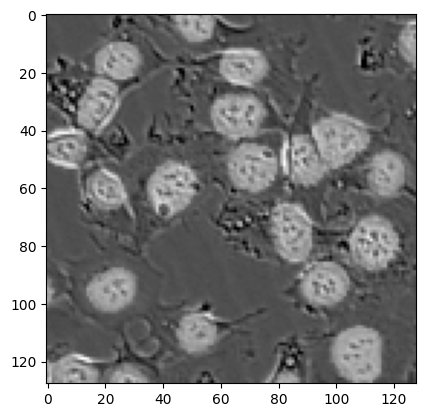

In [ ]:
i = 100 # change this value to view different images
plt.imshow(X_labeled[i]/255 + .5*y_labeled[i], cmap='gray')

In [ ]:
X_train, X_val, y_train, y_val = sk.model_selection.train_test_split(X_labeled, y_labeled, train_size=.8)

In [ ]:
X_test.shape

(2000, 128, 128)

In [ ]:
class CellsDataset():

  def __init__(self, dataArr, labelArr):
    self.dataArr = dataArr
    self.labelArr = labelArr

  def __len__(self):
    return len(self.dataArr)

  def __getitem__(self, i):
    x = self.dataArr[i]
    y = self.labelArr[i]

    x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)/255.0
    y = torch.tensor(y, dtype=torch.float32).unsqueeze(0)

    return x, y

In [ ]:
class CellsDatasetTest():

  def __init__(self, dataArr):
    self.dataArr = dataArr

  def __len__(self):
    return len(self.dataArr)

  def __getitem__(self, i):
    x = self.dataArr[i]

    x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)/255.0

    return x

In [ ]:
dataset_train = CellsDataset(X_train, y_train)
dataset_val = CellsDataset(X_val, y_val)
dataset_test = CellsDatasetTest(X_test)

dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=16, shuffle=True)
dataloader_val = torch.utils.data.DataLoader(dataset_val, batch_size=16, shuffle=False)
dataloader_test = torch.utils.data.DataLoader(dataset_test, batch_size=16, shuffle=False)

In [ ]:
test_batch = next(iter(dataloader_train))
print(test_batch[0].shape)
print(test_batch[1].shape)

torch.Size([16, 1, 128, 128])
torch.Size([16, 1, 128, 128])


In [ ]:
class UNet1(torch.nn.Module):

  def __init__(self):
    super().__init__()

    # Encode
    self.conv1 = torch.nn.Conv2d(1, 64, kernel_size=3, padding='same')
    self.conv2 = torch.nn.Conv2d(64, 64, kernel_size=3, padding='same')

    # Bottom
    self.conv3 = torch.nn.Conv2d(64, 128, kernel_size=3, padding='same')
    self.conv4 = torch.nn.Conv2d(128, 128, kernel_size=3, padding='same')
    self.conv5 = torch.nn.Conv2d(128, 64, kernel_size=3, padding='same')

    # Decode
    self.conv6 = torch.nn.Conv2d(128, 64, kernel_size=3, padding='same')
    self.conv7 = torch.nn.Conv2d(64, 64, kernel_size=3, padding='same')
    self.conv8 = torch.nn.Conv2d(64, 1, kernel_size=3, padding='same')

    self.relu = torch.nn.ReLU()
    self.maxpool = torch.nn.MaxPool2d(kernel_size=2, stride=2)
    self.upsample = torch.nn.Upsample(scale_factor=2)

  def forward(self, x):

    x = self.conv1(x)
    x = self.relu(x)
    x = self.conv2(x)
    x = self.relu(x)
    copy1 = x
    x = self.maxpool(x)

    x = self.conv3(x)
    x = self.relu(x)
    x = self.conv4(x)
    x = self.relu(x)

    x = self.upsample(x)
    x = self.conv5(x)
    x = self.relu(x)

    x = torch.cat((copy1, x), dim=1)
    x = self.conv6(x)
    x = self.relu(x)
    x = self.conv7(x)
    x = self.relu(x)
    x = self.conv8(x)

    return x

In [ ]:
class UNet2(torch.nn.Module):

  def __init__(self):
    super().__init__()

    # Encode
    self.conv1 = torch.nn.Conv2d(1, 64, kernel_size=3, padding='same')
    self.conv2 = torch.nn.Conv2d(64, 64, kernel_size=3, padding='same')

    self.conv3 = torch.nn.Conv2d(64, 128, kernel_size=3, padding='same')
    self.conv4 = torch.nn.Conv2d(128, 128, kernel_size=3, padding='same')

    self.conv5 = torch.nn.Conv2d(128, 256, kernel_size=3, padding='same')
    self.conv6 = torch.nn.Conv2d(256, 256, kernel_size=3, padding='same')

    self.conv7 = torch.nn.Conv2d(256, 512, kernel_size=3, padding='same')
    self.conv8 = torch.nn.Conv2d(512, 512, kernel_size=3, padding='same')

    # Bottom
    self.conv9 = torch.nn.Conv2d(512, 1024, kernel_size=3, padding='same')
    self.conv10 = torch.nn.Conv2d(1024, 1024, kernel_size=3, padding='same')
    self.conv11 = torch.nn.Conv2d(1024, 512, kernel_size=3, padding='same')

    # Decode
    self.conv12 = torch.nn.Conv2d(1024, 512, kernel_size=3, padding='same')
    self.conv13 = torch.nn.Conv2d(512, 512, kernel_size=3, padding='same')
    self.conv14 = torch.nn.Conv2d(512, 256, kernel_size=3, padding='same')

    self.conv15 = torch.nn.Conv2d(512, 256, kernel_size=3, padding='same')
    self.conv16 = torch.nn.Conv2d(256, 256, kernel_size=3, padding='same')
    self.conv17 = torch.nn.Conv2d(256, 128, kernel_size=3, padding='same')

    self.conv18 = torch.nn.Conv2d(256, 128, kernel_size=3, padding='same')
    self.conv19 = torch.nn.Conv2d(128, 128, kernel_size=3, padding='same')
    self.conv20 = torch.nn.Conv2d(128, 64, kernel_size=3, padding='same')

    self.conv21 = torch.nn.Conv2d(128, 64, kernel_size=3, padding='same')
    self.conv22 = torch.nn.Conv2d(64, 64, kernel_size=3, padding='same')
    self.conv23 = torch.nn.Conv2d(64, 1, kernel_size=3, padding='same')

    self.relu = torch.nn.ReLU()
    self.maxpool = torch.nn.MaxPool2d(kernel_size=2, stride=2)
    self.upsample = torch.nn.Upsample(scale_factor=2)

  def forward(self, x):

    #Down Conv Layer 1
    x = self.conv1(x)
    x = self.relu(x)
    x = self.conv2(x)
    x = self.relu(x)
    copy1 = x
    x = self.maxpool(x)

    #Down Conv Layer 2
    x = self.conv3(x)
    x = self.relu(x)
    x = self.conv4(x)
    x = self.relu(x)
    copy2 = x
    x = self.maxpool(x)

    #Down Conv Layer 3
    x = self.conv5(x)
    x = self.relu(x)
    x = self.conv6(x)
    x = self.relu(x)
    copy3 = x
    x = self.maxpool(x)

    #Down Conv Layer 4
    x = self.conv7(x)
    x = self.relu(x)
    x = self.conv8(x)
    x = self.relu(x)
    copy4 = x
    x = self.maxpool(x)

    #Bottem Layer (Up Conv)
    x = self.conv9(x)
    x = self.relu(x)
    x = self.conv10(x)
    x = self.relu(x)
    x = self.upsample(x)
    x = self.conv11(x)
    x = self.relu(x)

    # Up Conv 1
    x = torch.cat((copy4, x), dim=1)
    x = self.conv12(x)
    x = self.relu(x)
    x = self.conv13(x)
    x = self.relu(x)
    x = self.upsample(x)
    x = self.conv14(x)
    x = self.relu(x)

    # Up Conv 2
    x = torch.cat((copy3, x), dim=1)
    x = self.conv15(x)
    x = self.relu(x)
    x = self.conv16(x)
    x = self.relu(x)
    x = self.upsample(x)
    x = self.conv17(x)
    x = self.relu(x)

    # Up Conv 3
    x = torch.cat((copy2, x), dim=1)
    x = self.conv18(x)
    x = self.relu(x)
    x = self.conv19(x)
    x = self.relu(x)
    x = self.upsample(x)
    x = self.conv20(x)
    x = self.relu(x)

    # Final Layer
    x = torch.cat((copy1, x), dim=1)
    x = self.conv21(x)
    x = self.relu(x)
    x = self.conv22(x)
    x = self.relu(x)
    x = self.conv23(x)

    return x

In [ ]:
class UNet3(torch.nn.Module):

  def __init__(self):
    super().__init__()

    # Encode
    self.conv1 = torch.nn.Conv2d(1, 64, kernel_size=3, padding='same')
    self.conv2 = torch.nn.Conv2d(64, 64, kernel_size=3, padding='same')

    self.conv3 = torch.nn.Conv2d(64, 128, kernel_size=3, padding='same')
    self.conv4 = torch.nn.Conv2d(128, 128, kernel_size=3, padding='same')

    self.conv5 = torch.nn.Conv2d(128, 256, kernel_size=3, padding='same')
    self.conv6 = torch.nn.Conv2d(256, 256, kernel_size=3, padding='same')

    self.conv7 = torch.nn.Conv2d(256, 512, kernel_size=3, padding='same')
    self.conv8 = torch.nn.Conv2d(512, 512, kernel_size=3, padding='same')

    # NEW HERE
    self.conv9 = torch.nn.Conv2d(512, 1024, kernel_size=3, padding='same')
    self.conv10 = torch.nn.Conv2d(1024, 1024, kernel_size=3, padding='same')

    # Bottom
    self.conv11 = torch.nn.Conv2d(1024, 2048, kernel_size=3, padding='same')
    self.conv12 = torch.nn.Conv2d(2048, 2048, kernel_size=3, padding='same')
    self.conv13 = torch.nn.Conv2d(2048, 1024, kernel_size=3, padding='same')

    # Decode
    # NEW HERE
    self.conv14 = torch.nn.Conv2d(2048, 1024, kernel_size=3, padding='same')
    self.conv15 = torch.nn.Conv2d(1024, 1024, kernel_size=3, padding='same')
    self.conv16 = torch.nn.Conv2d(1024, 512, kernel_size=3, padding='same')

    self.conv17 = torch.nn.Conv2d(1024, 512, kernel_size=3, padding='same')
    self.conv18 = torch.nn.Conv2d(512, 512, kernel_size=3, padding='same')
    self.conv19 = torch.nn.Conv2d(512, 256, kernel_size=3, padding='same')

    self.conv20 = torch.nn.Conv2d(512, 256, kernel_size=3, padding='same')
    self.conv21 = torch.nn.Conv2d(256, 256, kernel_size=3, padding='same')
    self.conv22 = torch.nn.Conv2d(256, 128, kernel_size=3, padding='same')

    self.conv23 = torch.nn.Conv2d(256, 128, kernel_size=3, padding='same')
    self.conv24 = torch.nn.Conv2d(128, 128, kernel_size=3, padding='same')
    self.conv25 = torch.nn.Conv2d(128, 64, kernel_size=3, padding='same')

    self.conv26 = torch.nn.Conv2d(128, 64, kernel_size=3, padding='same')
    self.conv27 = torch.nn.Conv2d(64, 64, kernel_size=3, padding='same')
    self.conv28 = torch.nn.Conv2d(64, 1, kernel_size=3, padding='same')

    self.relu = torch.nn.ReLU()
    self.maxpool = torch.nn.MaxPool2d(kernel_size=2, stride=2)
    self.upsample = torch.nn.Upsample(scale_factor=2)

  def forward(self, x):

    # Down Conv Layer 1
    x = self.conv1(x)
    x = self.relu(x)
    x = self.conv2(x)
    x = self.relu(x)
    copy1 = x
    x = self.maxpool(x)

    # Down Conv Layer 2
    x = self.conv3(x)
    x = self.relu(x)
    x = self.conv4(x)
    x = self.relu(x)
    copy2 = x
    x = self.maxpool(x)

    # Down Conv Layer 3
    x = self.conv5(x)
    x = self.relu(x)
    x = self.conv6(x)
    x = self.relu(x)
    copy3 = x
    x = self.maxpool(x)

    # Down Conv Layer 4
    x = self.conv7(x)
    x = self.relu(x)
    x = self.conv8(x)
    x = self.relu(x)
    copy4 = x
    x = self.maxpool(x)

    # NEW Down Conv Layer 4
    x = self.conv9(x)
    x = self.relu(x)
    x = self.conv10(x)
    x = self.relu(x)
    copy5 = x
    x = self.maxpool(x)

    # Bottem Layer (Up Conv)
    x = self.conv11(x)
    x = self.relu(x)
    x = self.conv12(x)
    x = self.relu(x)
    x = self.upsample(x)
    x = self.conv13(x)
    x = self.relu(x)

    # NEW Up Conv 1
    x = torch.cat((copy5, x), dim=1)
    x = self.conv14(x)
    x = self.relu(x)
    x = self.conv15(x)
    x = self.relu(x)
    x = self.upsample(x)
    x = self.conv16(x)
    x = self.relu(x)

  # Up Conv 1
    x = torch.cat((copy4, x), dim=1)
    x = self.conv17(x)
    x = self.relu(x)
    x = self.conv18(x)
    x = self.relu(x)
    x = self.upsample(x)
    x = self.conv19(x)
    x = self.relu(x)

    # Up Conv 2
    x = torch.cat((copy3, x), dim=1)
    x = self.conv20(x)
    x = self.relu(x)
    x = self.conv21(x)
    x = self.relu(x)
    x = self.upsample(x)
    x = self.conv22(x)
    x = self.relu(x)

    # Up Conv 3
    x = torch.cat((copy2, x), dim=1)
    x = self.conv23(x)
    x = self.relu(x)
    x = self.conv24(x)
    x = self.relu(x)
    x = self.upsample(x)
    x = self.conv25(x)
    x = self.relu(x)

    # Final Layer
    x = torch.cat((copy1, x), dim=1)
    x = self.conv26(x)
    x = self.relu(x)
    x = self.conv27(x)
    x = self.relu(x)
    x = self.conv28(x)

    return x

In [ ]:
# # Dimmention checking
# model = UNet3()

# test_input = torch.randn(16, 1, 128, 128)

# output = model(test_input)

# print(f'Output shape: {output.shape}')

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Current Device: {device}')
model = UNet2().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=.00015)
loss_fun = torch.nn.BCEWithLogitsLoss()

num_epochs = 250
loss_vals_train = []
loss_vals_val = []
ep_count_mae_vals = []

minModel = UNet2().to(device)
minMAE = np.inf
minMAEep = 0

for ep in range(num_epochs):
  print(f'Epoch: {ep}')
  model.train()

  for x_batch, y_batch in dataloader_train:
    x_batch = x_batch.to(device)
    y_batch = y_batch.to(device)

    outputs = model(x_batch)
    loss = loss_fun(outputs, y_batch)
    model.zero_grad()
    loss.backward()
    optimizer.step()

  model.eval()

  with torch.no_grad():
    total_train_loss = 0
    for x_batch, y_batch in dataloader_train:
      x_batch = x_batch.to(device)
      y_batch = y_batch.to(device)

      y_pred = model(x_batch)
      loss = loss_fun(y_pred, y_batch)
      total_train_loss += loss.item() * x_batch.size(0)

    total_val_loss = 0
    count_mae_vals = []
    for x_batch, y_batch in dataloader_val:
      x_batch = x_batch.to(device)
      y_batch = y_batch.to(device)

      y_pred = model(x_batch)
      loss = loss_fun(y_pred, y_batch)
      total_val_loss += loss.item() * x_batch.size(0)

      counts_pred = []
      counts_val = []
      for i in range(y_pred.shape[0]):
        pred_img = (y_pred[i].squeeze().cpu().detach().numpy() > 0).astype(np.uint8)
        cc_info = cv2.connectedComponents(pred_img)
        counts_pred.append(cc_info[0] - 1)

        val_img = (y_batch[i].squeeze().cpu().detach().numpy() > 0).astype(np.uint8)
        cc_info = cv2.connectedComponents(val_img)
        counts_val.append(cc_info[0] - 1)

      count_mae_vals.append(np.mean(np.abs(np.array(counts_pred) - np.array(counts_val))))

  avg_train_loss = total_train_loss / len(dataloader_train.dataset)
  loss_vals_train.append(avg_train_loss)
  print(f'Average Training Loss: {avg_train_loss}')

  avg_val_loss = total_val_loss / len(dataloader_val.dataset)
  loss_vals_val.append(avg_val_loss)
  print(f'Average Validation Loss: {avg_val_loss}')

  ep_mae_val = np.mean(count_mae_vals)
  ep_count_mae_vals.append(ep_mae_val)
  print(f'Mean Absolute Count Error: {ep_mae_val}')

  if ep_mae_val < minMAE and ep > 30:
    minMAE = ep_mae_val
    minMAEep = ep
    minModel = copy.deepcopy(model)

  print('-'*20)

print(f'Minimized MAE: {minMAE}, at epoch {minMAEep}')

Current Device: cuda
Epoch: 0
Average Training Loss: 0.3872463569045067
Average Validation Loss: 0.3774315631389618
Mean Absolute Count Error: 11.5825
--------------------
Epoch: 1
Average Training Loss: 0.3016260074079037
Average Validation Loss: 0.2961220121383667
Mean Absolute Count Error: 4.51
--------------------
Epoch: 2
Average Training Loss: 0.24994811698794364
Average Validation Loss: 0.2436468243598938
Mean Absolute Count Error: 3.14
--------------------
Epoch: 3
Average Training Loss: 0.22279608398675918
Average Validation Loss: 0.2152349954843521
Mean Absolute Count Error: 3.225
--------------------
Epoch: 4
Average Training Loss: 0.19728842601180077
Average Validation Loss: 0.19105239629745482
Mean Absolute Count Error: 2.81
--------------------
Epoch: 5
Average Training Loss: 0.18616295337677002
Average Validation Loss: 0.1802116197347641
Mean Absolute Count Error: 2.46
--------------------
Epoch: 6
Average Training Loss: 0.17889721497893332
Average Validation Loss: 0.173

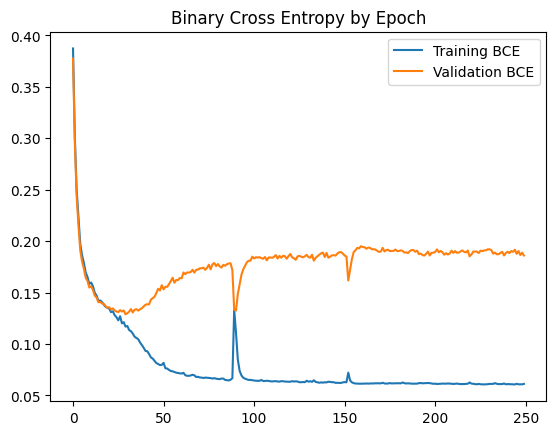

In [ ]:
plt.figure()
plt.plot(loss_vals_train, label='Training BCE')
plt.plot(loss_vals_val, label='Validation BCE')
plt.legend()
plt.title("Binary Cross Entropy by Epoch")
plt.show()

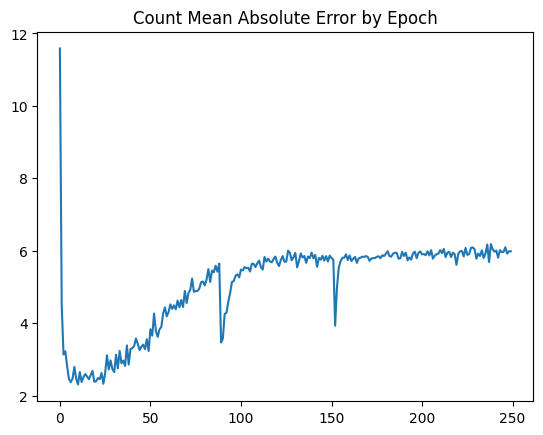

In [ ]:
plt.figure()
plt.plot(ep_count_mae_vals)
plt.title("Count Mean Absolute Error by Epoch")
plt.show()

In [ ]:
def sigmoid(x):
    return np.exp(x)/(1 + np.exp(x))

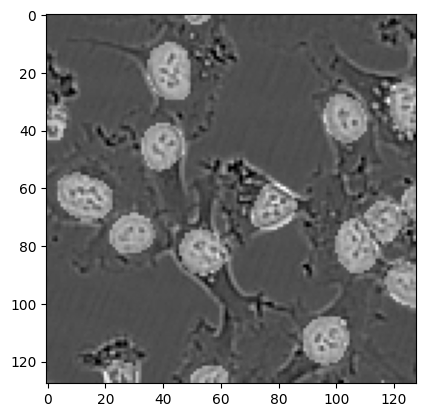

In [ ]:
test_x = next(iter(dataloader_test))[5]
test_x = test_x.unsqueeze(0).to(device)

test_y_pred = model(test_x)
test_y_pred = test_y_pred.squeeze().cpu().detach()
test_y_pred = np.round(sigmoid(test_y_pred.numpy()))
test_x = test_x.squeeze().cpu()

plt.imshow(test_x + 0.5 * test_y_pred, cmap='gray')
plt.show()

In [ ]:
bias = 0

cc_vals = []
for x_batch in dataloader_test:
    x_batch = x_batch.to(device)

    y_pred = model(x_batch)

    for i in range(y_pred.shape[0]):
        pred_img = y_pred[i].squeeze().cpu().detach().numpy()

        pred_img = (pred_img > 0).astype(np.uint8)

        cc_info = cv2.connectedComponents(pred_img)
        count = cc_info[0] - 1 + bias
        cc_vals.append(count)

In [ ]:
df = pd.DataFrame({
    'index': range(len(cc_vals)),
    'count': cc_vals
})

df.to_csv('finalProjectKaggleSubmission.csv', index=False)